# Compute average PSD

This notebook builds on the EEG analysis in lab to compute an average PSD for different conditions.

## Step 1 
Export all of the **LabChart Text Files (.txt)** for your conditions separately. Then, run the cell below which will create as many folders for you as you have conditions.

In [1]:
# Rename the conditions here!
conditions = ['Control', 'Treatment']

for condition in conditions:
    !mkdir -p {condition}

print("Directories created for conditions: " + ", ".join(conditions))

Directories created for conditions: Control, Treatment


## Step 2
Upload your exported .txt files into their respective folders.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob

filenames = {}

for condition in conditions:
    print(f"Files for {condition}:")
    filenames[condition] = glob.glob(f'{condition}/*.txt')
    print(filenames[condition])

Files for Control:
['Control/eyes open .txt', 'Control/EEG_Trial1_EyesOpen.txt', 'Control/EEG Eyes Open.txt']
Files for Treatment:
['Treatment/eyes closed.txt', 'Treatment/EEG_Trial1_EyesClosed.txt', 'Treatment/EEG Eyes Closed.txt']


## Step 3
Run the cell below to define several helper functions. You should also change the sampling frequency if you changed it for some reason.

In [3]:
# Change this if it was different for your experiment!
sampling_freq = 400
nperseg = 800  # Window length in samples (2 seconds at 400 Hz)

def generate_avg_psd(filenames):
  if len(filenames) == 0:
    return np.array([]), np.array([]), np.array([])

  psd_list = []
  freqs = None

  for file in filenames:
    print(file)
    columns = ['time', 'recording']
    data = np.genfromtxt(file, dtype=float, usecols=(0,1), skip_header=6, delimiter='\t', names=columns, encoding='unicode_escape')

    recording = data['recording']
    
    # Interpolate NaN values
    nans = np.isnan(recording)
    x = np.arange(len(recording))
    recording[nans] = np.interp(x[nans], x[~nans], recording[~nans])

    freqs, psd_single = signal.welch(recording, sampling_freq, nperseg=nperseg)
    psd_list.append(psd_single)

  # Interpolate all PSDs to same length
  max_len = max(len(p) for p in psd_list)
  psd_matrix = np.zeros((max_len, len(filenames)))

  for i, psd in enumerate(psd_list):
    if len(psd) < max_len:
      psd = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(psd)), psd)
    psd_matrix[:, i] = psd

  average_psd = np.mean(psd_matrix, axis=1)
  std_psd = np.std(psd_matrix, axis=1) / np.sqrt(len(filenames))

  return average_psd, std_psd, freqs

def plot_psd(average_psd, std_psd, freqs, label=None):
  plt.semilogy(freqs, average_psd, label=label)
  plt.fill_between(freqs, average_psd - std_psd, average_psd + std_psd, alpha=0.3)

  plt.xlabel('Frequency (Hz)')
  plt.ylabel('Power spectral density (µV^2 / Hz)') 

  max_freq = 75
  plt.xlim([0, max_freq]) 
  
  visible_mask = freqs <= max_freq
  ymin = min((average_psd - std_psd)[visible_mask])
  ymax = max((average_psd + std_psd)[visible_mask])
  plt.ylim(ymin, ymax)

## Step 4
Run the cell below to use the functions to calculate your average PSD and then plot for all of your conditions.

Control/eyes open .txt
Control/EEG_Trial1_EyesOpen.txt
Control/EEG Eyes Open.txt
Treatment/eyes closed.txt
Treatment/EEG_Trial1_EyesClosed.txt
Treatment/EEG Eyes Closed.txt


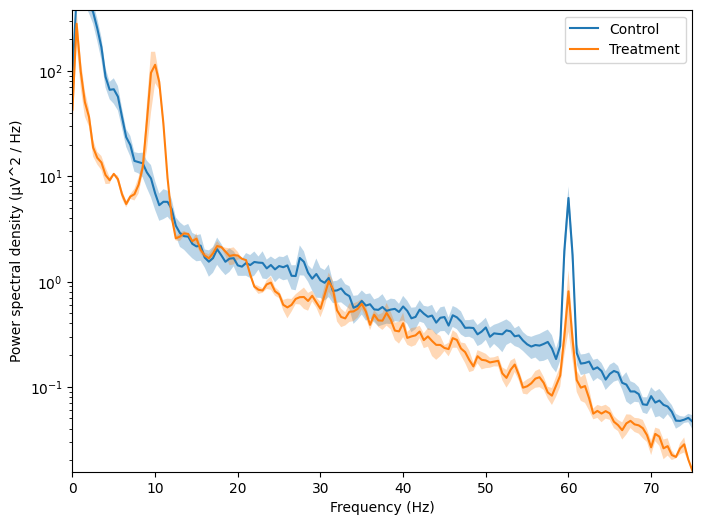

In [4]:
average_psd = {}
std_psd = {}

plt.figure(figsize=(8, 6))

for condition in conditions:
    average_psd[condition], std_psd[condition], freqs = generate_avg_psd(filenames[condition])
    plot_psd(average_psd[condition],std_psd[condition],freqs, label=condition)

plt.legend()
plt.show()